Using neuroCombat, harmonizing variables that we want to "clean out" of the data 

In [16]:
import pandas as pd
import neuroCombat
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
print(df.columns)

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path',
       'classification_label'],
      dtype='object')


In [17]:
tested_batch = 'manufacturer'  # Column indicating the batch variable
batch_definition = ['manufacturer', 'institute'] # Columns defining the batch, ADD TESLA
dependent_vars = ['birth_year', 'age_in_years', 'sex_c']

1. Data Matrix (df_features) - rows are imaging features (454 brain regions) and columns are individual scans (subjects).
2. Covariate Table (df_covariates)- row is a subject and columns include:
    a. Batch ID: The unique identifier for the scanner/site.
    b. Biological Covariates: Variables you want to protect (Age, Sex, Diagnosis).

In [18]:
# df_features has regions as columns (454) and subjects as rows (1000+), and the data is volume measurements
df_features = df.pivot_table(
    index='subject_id', 
    columns='region_label', 
    values='volume_mm3', 
    aggfunc='mean' # or 'sum', etc.
)

# index is subject_id, order them 
df_features = df_features.sort_index()

df_covariates = df.drop_duplicates(subset=['subject_id'])[
    ['subject_id', 'sex', 'institute', 'manufacturer', 'age_in_years',  'birth_year']] # add protocol and tiv, but notice they're missing for some subjects

# create sex_c column
df_covariates['sex_c'] = df_covariates['sex'].map({'M': 0, 'F': 1})

# index is subject_id, order them 
df_covariates = df_covariates.set_index('subject_id').sort_index()

# validate alignment
print("Covariates Index (first 5):", df_covariates.index[:5].tolist())
print("Before Features Index (first 5):", df_features.index[:5].tolist())

Covariates Index (first 5): ['0873', 'BB00005', 'BB01209', 'BBK0001', 'BBK0002']
Before Features Index (first 5): ['0873', 'BB00005', 'BB01209', 'BBK0001', 'BBK0002']


In [19]:
# 1. Create the Super-Batch ID
df_covariates['super_batch'] = (
    df_covariates['institute'].astype(str) + "_" + 
    df_covariates['manufacturer'].astype(str)
)

# Before Harmonization


1. check collinearity between the batch and the features, to make sure I don't harmonize features (brain volume)
 If they overlap (earlier birth years correlation with institute = 1 I have collinearity and harmonizing can harm the biological effect)

In [20]:
from scipy.stats import chi2_contingency
# Check if Diagnosis is confounded with batch
confound_check = pd.crosstab(df_covariates['super_batch'], df_covariates['birth_year'])
print(confound_check)

chi2, p, dof, ex = chi2_contingency(confound_check)
print(f"Chi-square p-value: {p}")

birth_year                                 1900  1911  1912  1917  1919  1921  \
super_batch                                                                     
ICHILOV TEL AVIV_GE MEDICAL SYSTEMS           0     1     1     1     1     1   
SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS     1     0     0     0     0     0   
Tel-Aviv University_SIEMENS                   0     0     0     0     0     0   

birth_year                                 1922  1924  1925  1926  ...  2001  \
super_batch                                                        ...         
ICHILOV TEL AVIV_GE MEDICAL SYSTEMS           2     1     3     1  ...     0   
SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS     0     0     0     0  ...     0   
Tel-Aviv University_SIEMENS                   0     0     0     0  ...   132   

birth_year                                 2002  2003  2004  2005  2006  2007  \
super_batch                                                                     
ICHILOV TEL AVIV_GE MEDICAL SYS

In [21]:
# to handle collinearity, set scans from snbb as the reference batch


2. make sure the subgroups in the batch are big enough to be meaningful

In [22]:
# 2. Count subjects per batch
batch_counts = df_covariates['super_batch'].value_counts()
print("--- Batch Size Summary ---")
print(batch_counts)

small_batches = batch_counts[batch_counts < 5].index.tolist()
if small_batches:
    print(f"\nWarning: Batches with < 5 subjects: {small_batches}")

--- Batch Size Summary ---
super_batch
Tel-Aviv University_SIEMENS                  3080
ICHILOV TEL AVIV_GE MEDICAL SYSTEMS           511
SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS     166
Name: count, dtype: int64


3. look for missing values and remove them (as neuroCombat can't handle missing values)

In [23]:
# are there any missing values?
print("Missing values in df_features:", df_features.isnull().sum().sum())

# separate the entries with missing values
missing_values_features = df_features[df_features.isnull().any(axis=1)]
print("Missing values in df_covariates:", df_covariates.isnull().sum())

Missing values in df_features: 231
Missing values in df_covariates: sex             0
institute       0
manufacturer    0
age_in_years    0
birth_year      0
sex_c           0
super_batch     0
dtype: int64


In [24]:
# remove entries with missing values from both dataframes
df_features = df_features.dropna()
df_covariates = df_covariates.loc[df_features.index]

# Batch distributions of biological features


--- Confounding Check (Batch vs. Birth Year) ---


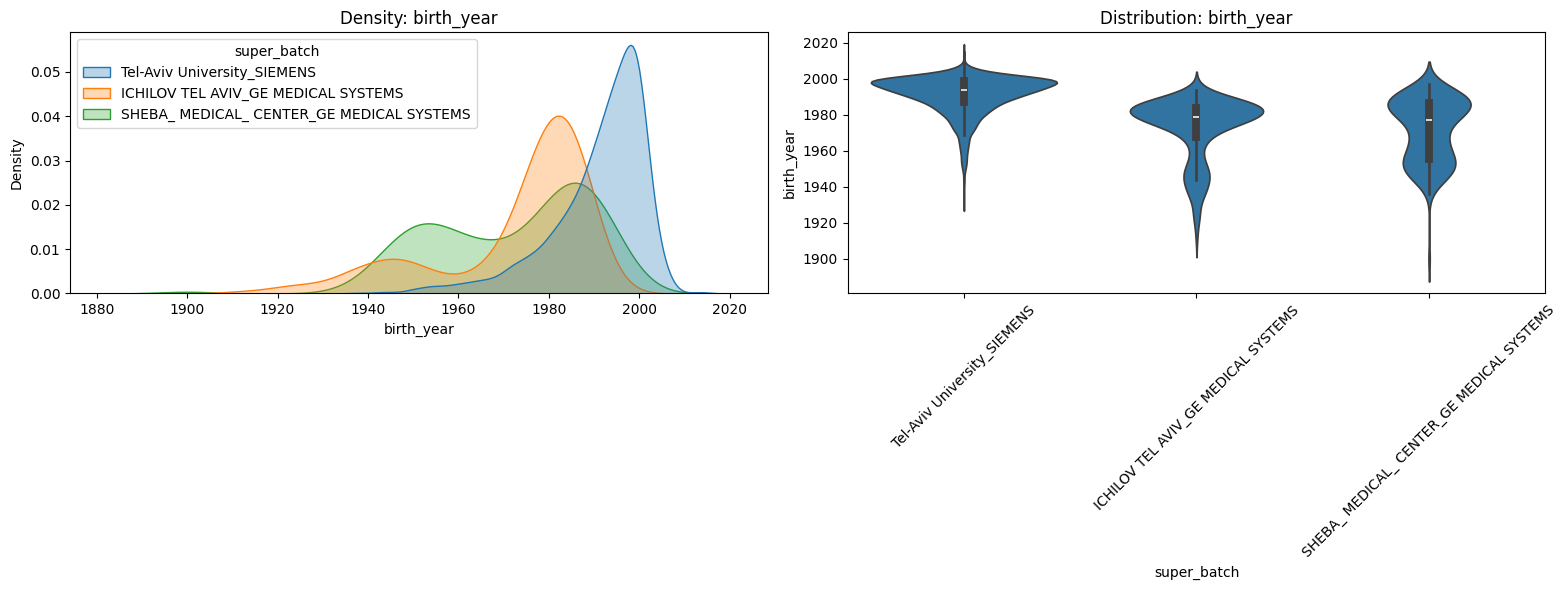

ANOVA F-statistic: 650.0995
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. birth_year differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Age In Years) ---


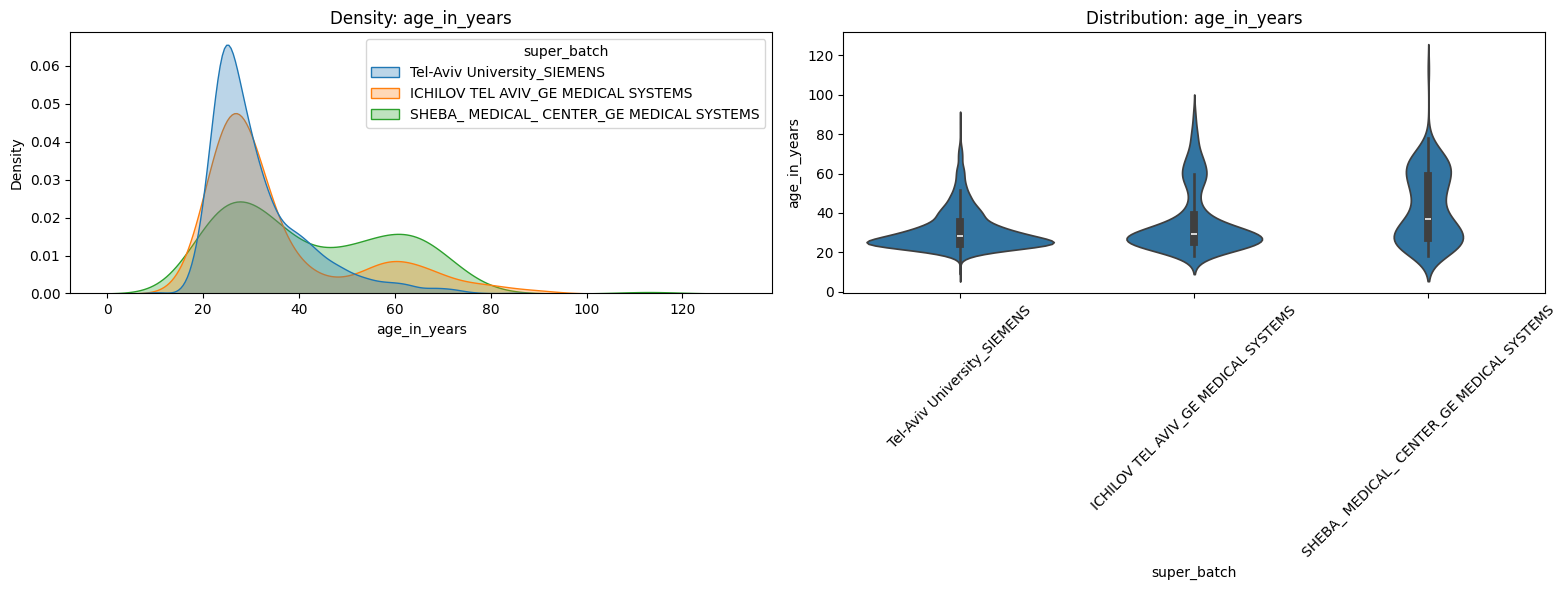

ANOVA F-statistic: 92.1466
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. age_in_years differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Sex C) ---


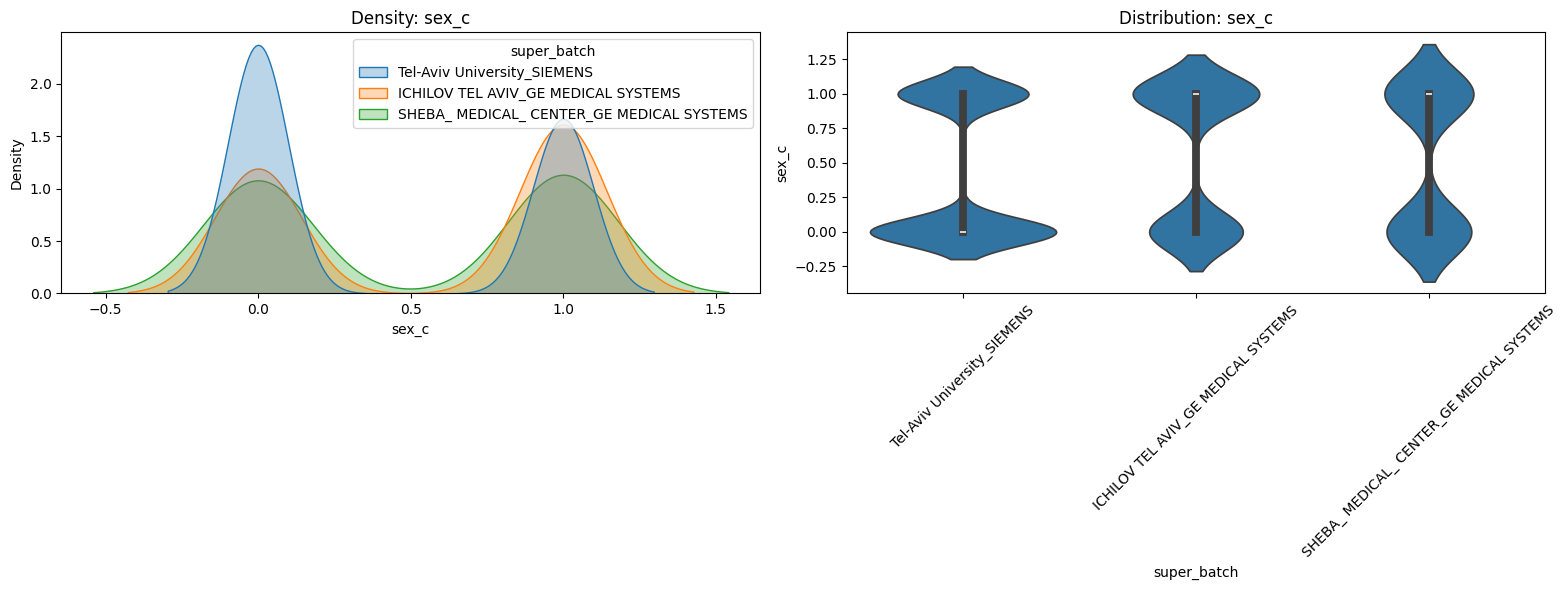

ANOVA F-statistic: 25.4298
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. sex_c differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.


In [25]:
def check_confounding(df, var_name):
    print(f"\n--- Confounding Check (Batch vs. {var_name.replace('_', ' ').title()}) ---")

    batch_col = 'super_batch'

    # 2. Create Plotting Grid (Two plots side-by-side for efficiency)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # KDE Plot
    sns.kdeplot(data=df, x=var_name, hue=batch_col, 
                fill=True, alpha=0.3, ax=axes[0], common_norm=False)
    axes[0].set_title(f"Density: {var_name}")
    
    # Violin Plot
    sns.violinplot(data=df, x=batch_col, y=var_name, ax=axes[1])
    axes[1].set_title(f"Distribution: {var_name}")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

    # 3. Statistical Test (ANOVA)
    # Grouping data into a list of arrays for f_oneway
    groups = [group[var_name].values for _, group in df.groupby(batch_col)]
    
    f_stat, p_val = stats.f_oneway(*groups)

    print(f"ANOVA F-statistic: {f_stat:.4f}")
    print(f"ANOVA p-value: {p_val:.4f}")

    if p_val < 0.05:
        print(f"ALERT: Strong confounding detected. {var_name} differs significantly across batches.")
        print("NeuroCombat will need to work harder to separate biological variance from site effects.")
    else:
        print(f"PASS: No significant difference in {var_name} across batches.")

# 4. Iterate over your list
for var in dependent_vars:
    check_confounding(df_covariates, var)

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import gaussian_kde
from scipy.integrate import simpson

def calculate_overlap(data, batch_col, var_col, batch_a, batch_b):
    """Calculates the area of overlap between two KDE distributions."""
    # Ensure numeric and clean
    vals_a = pd.to_numeric(data[data[batch_col] == batch_a][var_col], errors='coerce').dropna()
    vals_b = pd.to_numeric(data[data[batch_col] == batch_b][var_col], errors='coerce').dropna()
    
    if len(vals_a) < 5 or len(vals_b) < 5:  # Basic check for KDE stability
        return 0.0
    
    low, high = min(vals_a.min(), vals_b.min()), max(vals_a.max(), vals_b.max())
    x = np.linspace(low, high, 1000)
    
    # Calculate KDEs and find the minimum area
    kde_a, kde_b = gaussian_kde(vals_a)(x), gaussian_kde(vals_b)(x)
    overlap = simpson(y=np.minimum(kde_a, kde_b), x=x)
    return overlap

def print_overlap_report(var, b1, b2, score, data):
    """Prints a formatted report with status indicators."""
    status = "GOOD" if score >= 0.6 else "CAUTION" if score >= 0.3 else "CRITICAL"
    indicator = "✅" if status == "GOOD" else "⚠️" if status == "CAUTION" else "🚨"
    
    print(f"\n{'-'*60}")
    print(f"{indicator} Variable: {var.upper()} | {b1} vs {b2}")
    print(f"{'-'*60}")
    print(f"Overlap Score: {score:.4f} ({status})")
    
    if status == "CRITICAL":
        print("!! WARNING: Very low overlap. Site effects may be confounded with biological signal.")
    elif status == "CAUTION":
        print("!! NOTE: Moderate overlap. Check if NeuroCombat captures this in continuous_cols.")

# ---------------------------------------------------------
# Execution
# ---------------------------------------------------------
dependent_vars = ['birth_year', 'age_in_years'] # sex_c is usually handled via Chi-Sq
target_batches = df_covariates['super_batch'].unique()

for var in dependent_vars:
    # Ensure global numeric conversion for speed
    df_covariates[var] = pd.to_numeric(df_covariates[var], errors='coerce')
    
    for b1, b2 in combinations(target_batches, 2):
        score = calculate_overlap(df_covariates, 'super_batch', var, b1, b2)
        print_overlap_report(var, b1, b2, score, df_covariates)


------------------------------------------------------------
⚠️ Variable: BIRTH_YEAR | Tel-Aviv University_SIEMENS vs ICHILOV TEL AVIV_GE MEDICAL SYSTEMS
------------------------------------------------------------
Overlap Score: 0.4346 (CAUTION)
!! NOTE: Moderate overlap. Check if NeuroCombat captures this in continuous_cols.

------------------------------------------------------------
⚠️ Variable: BIRTH_YEAR | Tel-Aviv University_SIEMENS vs SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS
------------------------------------------------------------
Overlap Score: 0.5076 (CAUTION)
!! NOTE: Moderate overlap. Check if NeuroCombat captures this in continuous_cols.

------------------------------------------------------------
✅ Variable: BIRTH_YEAR | ICHILOV TEL AVIV_GE MEDICAL SYSTEMS vs SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS
------------------------------------------------------------
Overlap Score: 0.7224 (GOOD)

------------------------------------------------------------
✅ Variable: AG

# Run NeuroCombat

In [27]:
from neuroCombat import neuroCombat
# 2. Transpose features: NeuroCombat needs (features x subjects)
# We drop the 'SubjectID' column so only numerical brain data remains
data = df_features.transpose().to_numpy()

# 3. Define the batch (scanner/site)
batch = df_covariates[tested_batch].tolist()

# 4. Define biological covariates to PRESERVE
# 'categorical_cols' tells the model these are not continuous numbers
categorical_cols = ['sex']
continuous_cols = ['age_in_years', 'birth_year']

# 5. Run NeuroCombat
# eb=True uses Empirical Bayes to pool information across features
result = neuroCombat(dat=data,
                     covars=df_covariates,
                     batch_col='super_batch',
                     categorical_cols=categorical_cols,
                     continuous_cols=continuous_cols)

# 6. Extract the harmonized data
# The output is a dictionary; 'data' contains the corrected matrix
harmonized_data_matrix = result['data']
# convert back to DataFrame to keep track of indices and columns
harmonized_data_matrix = pd.DataFrame(harmonized_data_matrix,
                                      index=df_features.columns,
                                      columns=df_features.index)

# 7. Convert back to a DataFrame for analysis
df_harmonized = pd.DataFrame(harmonized_data_matrix.transpose(), 
                             columns=df_features.columns)

# sort indices to match original data
df_harmonized = df_harmonized.sort_index()

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


# Visualization

all regions together

In [63]:
# pick a region to visualize (e.g., column 1)
target_regions = [1, 20, 400]
# target_regions = list(range(1, 400, 50))

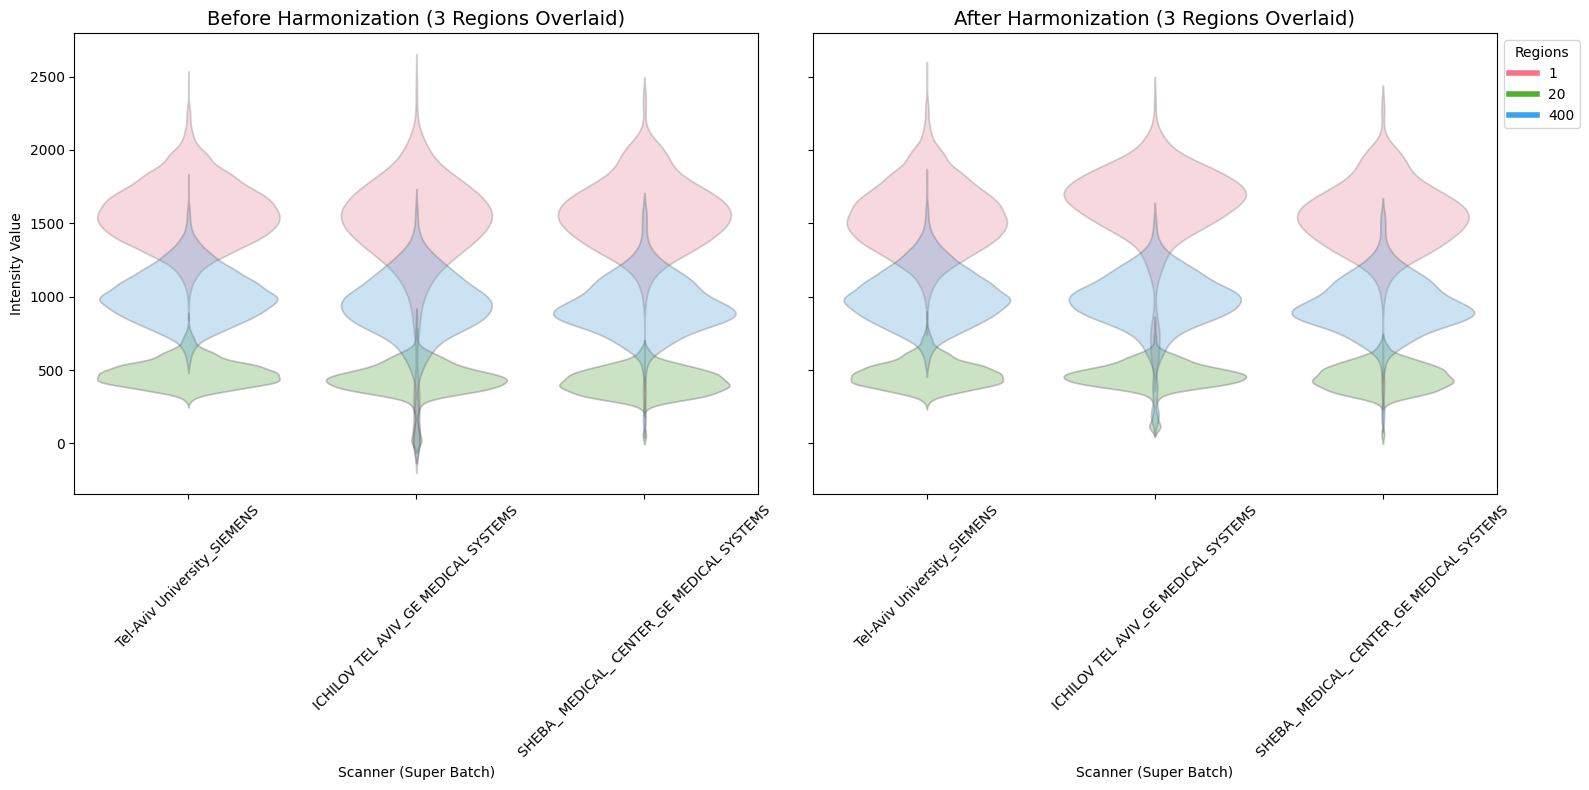

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# 1. Dynamically generate a palette based on the number of regions
num_regions = len(target_regions)
# 'husl' is good for many distinct colors; 'viridis' or 'tab10'/ 'tab20' are also options
palette = sns.color_palette("husl", num_regions)
region_color_map = dict(zip(target_regions, palette))

# 2. Create the Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# 3. Overlay the regions
for region in target_regions:
    # Prepare data for the current region
    plot_before = pd.concat([df_covariates['super_batch'], df_features[region]], axis=1)
    plot_after = pd.concat([df_covariates['super_batch'], df_harmonized[region]], axis=1)
    
    # Get the assigned color for this region
    reg_color = region_color_map[region]

    # Plot Before
    sns.violinplot(
        data=plot_before, x='super_batch', y=region, 
        ax=axes[0], color=reg_color, alpha=0.3, inner=None
    )
    
    # Plot After
    sns.violinplot(
        data=plot_after, x='super_batch', y=region, 
        ax=axes[1], color=reg_color, alpha=0.3, inner=None
    )

# 4. Formatting and Labels
axes[0].set_title(f"Before Harmonization ({num_regions} Regions Overlaid)", fontsize=14)
axes[1].set_title(f"After Harmonization ({num_regions} Regions Overlaid)", fontsize=14)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel("Scanner (Super Batch)")
    ax.set_ylabel("Intensity Value")

# 5. Create a Dynamic Legend
legend_elements = [
    Line2D([0], [0], color=region_color_map[reg], lw=4, label=str(reg)) 
    for reg in target_regions
]

# Adjust legend location if there are many regions
axes[1].legend(
    handles=legend_elements, 
    loc='upper left', 
    bbox_to_anchor=(1, 1), # Places legend outside the plot area
    title="Regions",
    ncol=1 if num_regions <= 10 else 2 # Splits legend into columns if list is long
)

plt.tight_layout()
plt.show()

each region in a separate plot

/tmp/ipykernel_827063/4249893249.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_before, x='super_batch', y=region, ax=axes[0], palette="Set2")
/tmp/ipykernel_827063/4249893249.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_after, x='super_batch', y=region, ax=axes[1], palette="Set2")


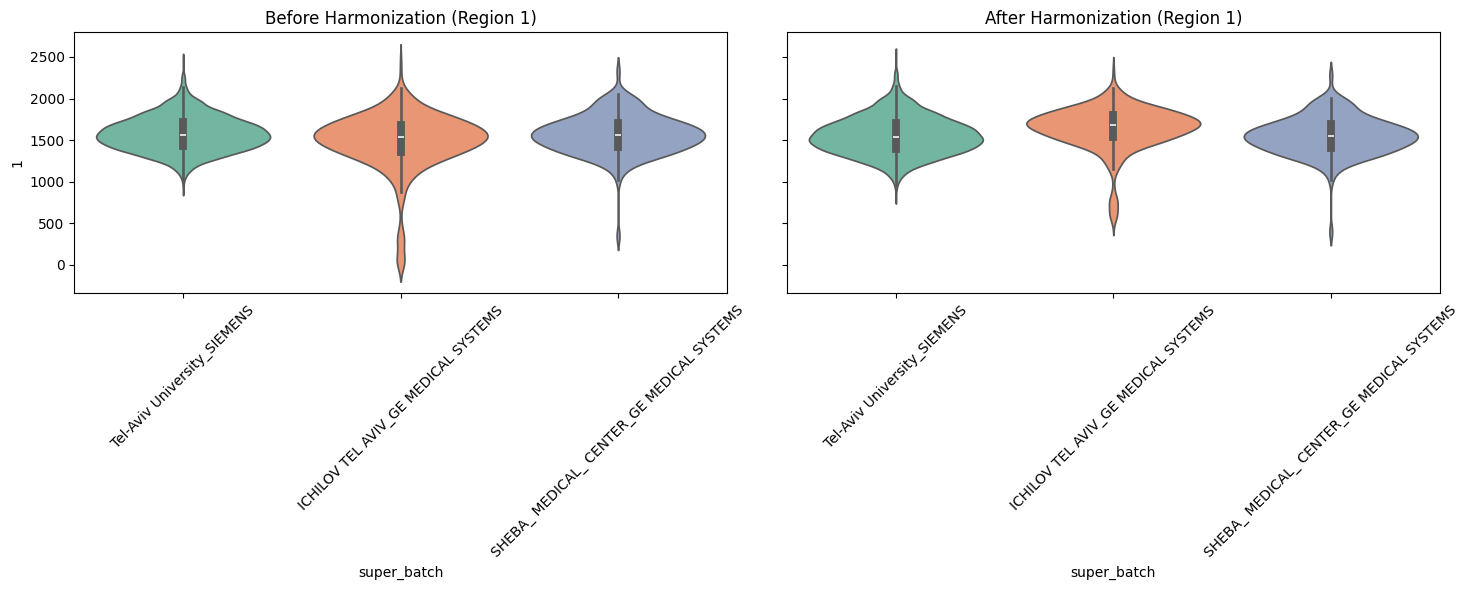

/tmp/ipykernel_827063/4249893249.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_before, x='super_batch', y=region, ax=axes[0], palette="Set2")
/tmp/ipykernel_827063/4249893249.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_after, x='super_batch', y=region, ax=axes[1], palette="Set2")


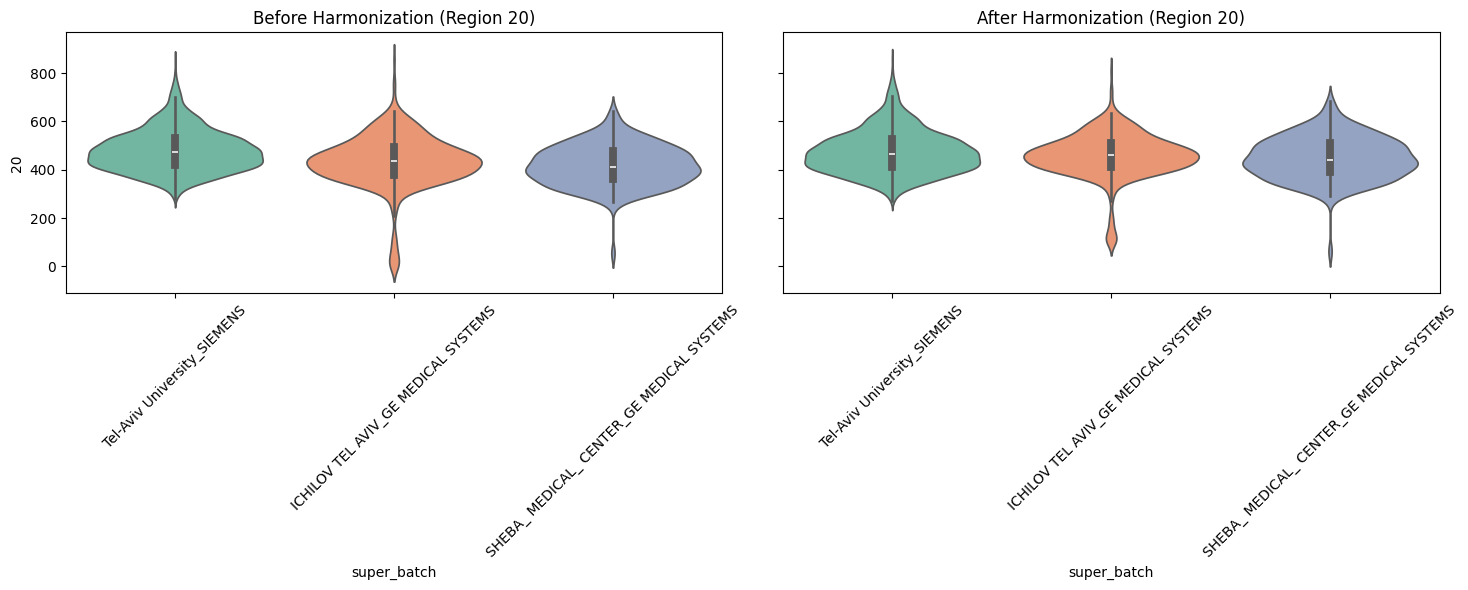

/tmp/ipykernel_827063/4249893249.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_before, x='super_batch', y=region, ax=axes[0], palette="Set2")
/tmp/ipykernel_827063/4249893249.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_after, x='super_batch', y=region, ax=axes[1], palette="Set2")


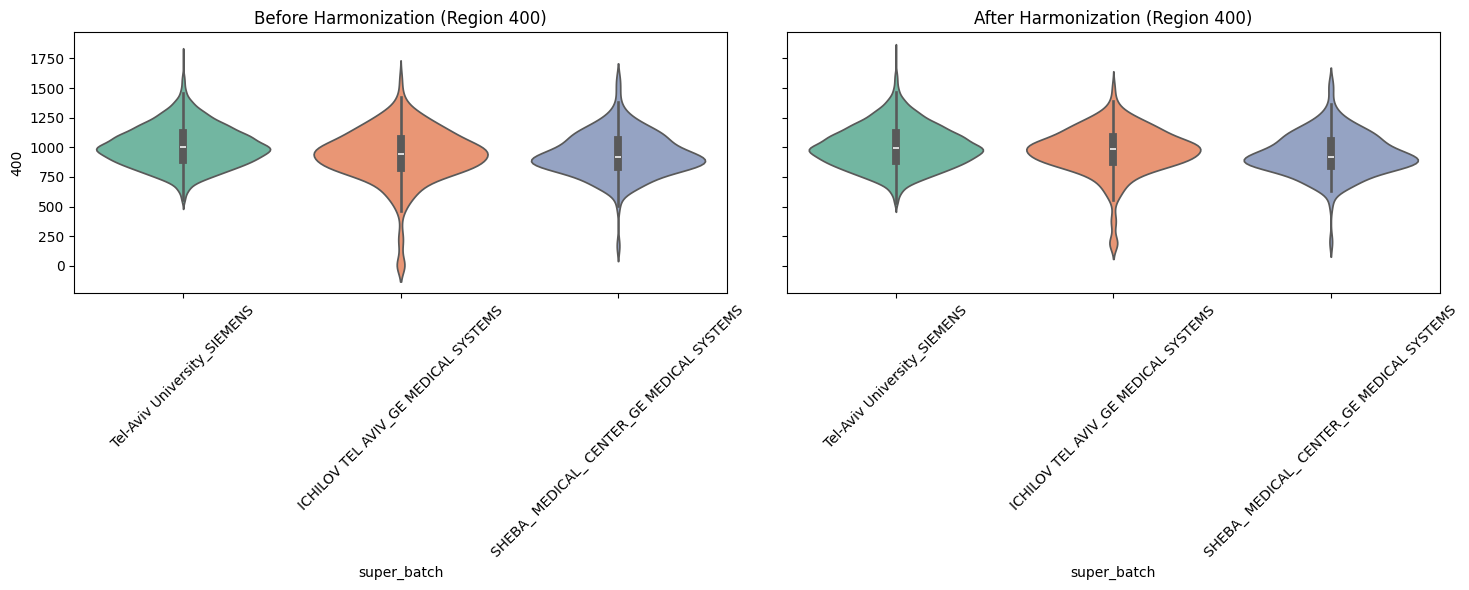

In [65]:
# 1. Prepare data for plotting
# We use the index-aligned dataframes we created before NeuroCombat
for region in target_regions:
    plot_before = pd.concat([df_covariates['super_batch'], df_features[region]], axis=1)
    plot_after = pd.concat([df_covariates['super_batch'], df_harmonized[region]], axis=1)

    # 2. Create Side-by-Side Plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    # Plot Before
    sns.violinplot(data=plot_before, x='super_batch', y=region, ax=axes[0], palette="Set2")
    axes[0].set_title(f"Before Harmonization (Region {region})")
    axes[0].tick_params(axis='x', rotation=45)

    # Plot After
    sns.violinplot(data=plot_after, x='super_batch', y=region, ax=axes[1], palette="Set2")
    axes[1].set_title(f"After Harmonization (Region {region})")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# merge harmonized data back to combined_df

In [66]:
# 1. Melt the harmonized data from wide back to long format
# We ensure the names match your original columns exactly
df_harmonized_long = df_harmonized.reset_index().melt(
    id_vars='subject_id', 
    var_name='region_label', 
    value_name='volume_mm3_harmonized'
)

# 2. Ensure types match for the merge keys
df_harmonized_long['subject_id'] = df_harmonized_long['subject_id'].astype(str)
df_harmonized_long['region_label'] = df_harmonized_long['region_label'].astype(int) # or str, matching original

# 3. Create the copy and merge
# We use a 'left' join to keep all 3 million original rows. 
# Subjects without harmonized data will naturally have NaN in the new column.
df_final = df.merge(
    df_harmonized_long, 
    on=['subject_id', 'region_label'], 
    how='left'
)

print(f"Merge complete. Original rows: {len(df)}, New rows: {len(df_final)}")
print(f"Columns now include: {df_final.columns.tolist()}")



Merge complete. Original rows: 2264144, New rows: 2264144
Columns now include: ['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3', 'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob', 'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0', 'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path', 'estimated_critical_info', 'scan_date', 'file_path', 'classification_label', 'volume_mm3_harmonized']


In [67]:
# save to pickle
df_final.to_pickle('/home/gaia/Projects/legacy_data/harmonized_gm_volumes.pkl')